# Stronger Equal-Budget Parrondo-Type Condition

This notebook validates a condition found by the extended parameter search.
Unlike the earlier example, every strategy is constrained to the same fixed
budget from the beginning.

The selected condition satisfies:

- Policy A alone is losing;
- Policy B alone is losing;
- A50B50 and B50A50 block schedules are losing;
- periodic AB and BA schedules are winning;
- fewer than half of the initially tested random schedules were winning.

This makes it a cleaner scheduling-dependent Parrondo-type candidate than the
original unrestricted-cost example.

In [1]:
from pathlib import Path
import os


current_path = Path.cwd().resolve()
repo_root = next(
    path
    for path in (current_path, *current_path.parents)
    if (path / "src").is_dir()
)
os.chdir(repo_root)

print(f"Repository root: {repo_root}")

Repository root: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model


## Load the search results and select the clean candidate

The candidate is selected from the block-validated finalists. It must have a
positive clean margin and a random-schedule winning fraction below 50%.

In [2]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import src.weed_ca
import src.weed_experiment
import src.weed_policies

importlib.reload(src.weed_ca)
importlib.reload(src.weed_policies)
importlib.reload(src.weed_experiment)

from src.weed_experiment import ExperimentConfig, run_experiment
from src.weed_policies import HighDensityRemovalPolicy, SpreadFrontRemovalPolicy

c:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\cits4403_weed_env_01\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
finalists_path = (
    repo_root / "results" / "strong_parrondo_finalists.csv"
)

finalists = pd.read_csv(finalists_path)

eligible = finalists[
    (finalists["clean_margin"] > 0)
    & (finalists["random_winning_fraction"] < 0.5)
].sort_values("clean_margin", ascending=False)

if eligible.empty:
    raise RuntimeError("No clean candidate was found")

candidate = eligible.iloc[0]

display_columns = [
    "sample_id", "clean_margin", "a_relative_change", "b_relative_change",
    "ab_relative_change", "ba_relative_change", "a50b50_relative_change",
    "b50a50_relative_change", "random_winning_fraction", "budget",
    "growth_rate", "diffusion_rate", "a_rate", "b_rate", "max_cells",
    "boundary", "b_lower",
]

candidate[display_columns]

sample_id                      2036
clean_margin               0.003486
a_relative_change          0.041958
b_relative_change          0.014206
ab_relative_change        -0.002064
ba_relative_change        -0.003486
a50b50_relative_change     0.047051
b50a50_relative_change     0.029926
random_winning_fraction        0.45
budget                       250000
growth_rate                    0.01
diffusion_rate                 0.01
a_rate                         0.15
b_rate                         0.65
max_cells                        50
boundary                        0.7
b_lower                        0.45
Name: 5, dtype: object

## Load the data and construct the selected configuration

The candidate currently selected by the search is expected to be sample
`2036`, with a common budget of `250,000` model-cost units.

In [4]:
from src.data_loader import load_locality_data


localities = load_locality_data()
metro = localities[
    localities["postcode"].astype(int).between(6000, 6199)
].copy()

config = ExperimentConfig(
    pressure_coef=0.000783,
    cell_size=1000.0,
    w_min=0.05,
    w_max=1.0,
    growth_rate=float(candidate["growth_rate"]),
    diffusion_rate=float(candidate["diffusion_rate"]),
    carrying_capacity=1.0,
    steps=100,
    high_density_threshold=0.7,
    crs="EPSG:7850",
)

COMMON_BUDGET = float(candidate["budget"])
UNIT_COST = 200.0

parameters = {
    "a_rate": float(candidate["a_rate"]),
    "b_rate": float(candidate["b_rate"]),
    "max_cells": int(candidate["max_cells"]),
    "boundary": float(candidate["boundary"]),
    "b_lower": float(candidate["b_lower"]),
}

print(f"Common budget: {COMMON_BUDGET:,.2f}")
print(parameters)

Common budget: 250,000.00
{'a_rate': 0.15, 'b_rate': 0.65, 'max_cells': 50, 'boundary': 0.7, 'b_lower': 0.45}


C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\src\data_loader.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  census["postcode"] = (


## Define schedule and budget wrappers

Every schedule receives the same maximum budget. If an action would exceed
the remaining budget, its removal amount is scaled proportionally. After the
budget is exhausted, growth and diffusion continue but removal becomes zero.

In [5]:
def make_policy_a():
    return HighDensityRemovalPolicy(
        threshold=parameters["boundary"],
        removal_rate=parameters["a_rate"],
        max_cells=parameters["max_cells"],
        unit_cost=UNIT_COST,
    )


def make_policy_b():
    return SpreadFrontRemovalPolicy(
        lower_threshold=parameters["b_lower"],
        upper_threshold=parameters["boundary"],
        removal_rate=parameters["b_rate"],
        max_cells=parameters["max_cells"],
        unit_cost=UNIT_COST,
    )


class ScheduledPolicy:
    '''Apply A and B according to a fixed sequence.'''

    def __init__(self, schedule):
        self.schedule = tuple(schedule)
        self.policy_a = make_policy_a()
        self.policy_b = make_policy_b()
        self.index = 0

    def reset(self):
        self.index = 0

    def __call__(self, weed_grid, valid_mask):
        label = self.schedule[self.index]
        self.index += 1
        policy = self.policy_a if label == "A" else self.policy_b
        return policy(weed_grid, valid_mask)


class BudgetLimitedPolicy:
    '''Limit cumulative policy expenditure.'''

    def __init__(self, policy, budget):
        self.policy = policy
        self.budget = float(budget)
        self.spent = 0.0

    def reset(self):
        self.spent = 0.0
        self.policy.reset()

    def __call__(self, weed_grid, valid_mask):
        diff, proposed_cost = self.policy(weed_grid, valid_mask)
        proposed_cost = float(proposed_cost)
        remaining = self.budget - self.spent

        if remaining <= 0 or proposed_cost <= 0:
            return np.zeros_like(weed_grid, dtype=np.float32), 0.0

        if proposed_cost <= remaining:
            self.spent += proposed_cost
            return diff, proposed_cost

        scale = remaining / proposed_cost
        self.spent = self.budget
        return np.asarray(diff, dtype=np.float32) * scale, remaining

## Define the deterministic schedules

All mixed schedules contain exactly 50 A and 50 B calls. The only difference
is their order.

In [6]:
steps = config.steps
half = steps // 2

schedules = {
    "A only": ["A"] * steps,
    "B only": ["B"] * steps,
    "AB": ["A", "B"] * half,
    "BA": ["B", "A"] * half,
    "A50B50": ["A"] * half + ["B"] * half,
    "B50A50": ["B"] * half + ["A"] * half,
}


def run_schedule(name, schedule):
    policy = BudgetLimitedPolicy(
        ScheduledPolicy(schedule),
        budget=COMMON_BUDGET,
    )

    return run_experiment(
        name=name,
        gdf=metro,
        config=config,
        policy=policy,
    )

## Rerun and verify the deterministic strategies

The strict validation requires A, B and both block controls to be losing,
while periodic AB and BA are winning under the same budget.

In [7]:
baseline_result = run_experiment(
    name="strong_baseline",
    gdf=metro,
    config=config,
)

results = {}
for name, schedule in tqdm(
    schedules.items(),
    total=len(schedules),
    desc="Equal-budget deterministic schedules",
):
    results[name] = run_schedule(name, schedule)


def summary_row(name, result):
    return {
        "strategy": name,
        "initial_mean": result.initial_mean,
        "final_mean": result.final_mean,
        "relative_change": result.relative_change,
        "winning": result.relative_change < 0,
        "high_density_cells": result.final_high_density_cells,
        "cumulative_weed": float(np.trapezoid(result.mean_weed)),
        "final_cost": result.final_cost,
    }


deterministic_summary = pd.DataFrame(
    [summary_row(name, result) for name, result in results.items()]
)

deterministic_summary

Equal-budget deterministic schedules: 100%|██████████| 6/6 [00:01<00:00,  4.16it/s]


,strategy,initial_mean,final_mean,relative_change,winning,high_density_cells,cumulative_weed,final_cost
0,A only,0.860575,0.896682,0.041958,False,6617,87.949112,149107.484375
1,B only,0.860575,0.872800,0.014206,False,5725,86.396667,199967.171875
2,AB,0.860575,0.858799,-0.002064,True,5886,85.803925,228212.656250
3,BA,0.860575,0.857575,-0.003486,True,5855,85.672371,229166.359375
4,A50B50,0.860575,0.901066,0.047051,False,6302,87.685555,138087.875000
5,B50A50,0.860575,0.886328,0.029926,False,6053,86.752548,173466.421875


In [8]:
assert results["A only"].relative_change > 0
assert results["B only"].relative_change > 0
assert results["A50B50"].relative_change > 0
assert results["B50A50"].relative_change > 0
assert results["AB"].relative_change < 0
assert results["BA"].relative_change < 0

for result in results.values():
    assert result.final_cost <= COMMON_BUDGET + 1e-2

print("Equal-budget block-controlled Parrondo checks passed.")

Equal-budget block-controlled Parrondo checks passed.


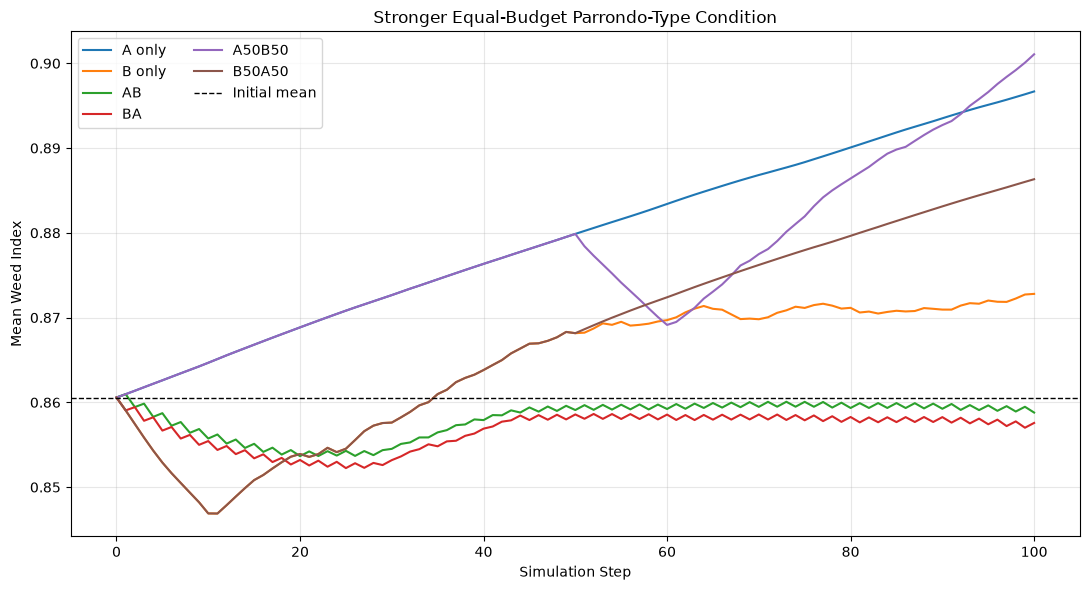

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

for name, result in results.items():
    ax.plot(result.mean_weed, label=name)

ax.axhline(
    baseline_result.initial_mean,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Initial mean",
)

ax.set_title("Stronger Equal-Budget Parrondo-Type Condition")
ax.set_xlabel("Simulation Step")
ax.set_ylabel("Mean Weed Index")
ax.grid(alpha=0.3)
ax.legend(ncol=2)

plt.tight_layout()
plt.show()

## Validate against 100 random 50A/50B schedules

Random schedules use exactly the same numbers of A and B calls and the same
budget. A low random winning fraction indicates that the temporal structure
of the periodic schedule matters.

In [10]:
RANDOM_SEEDS = range(100)
random_records = []

for seed in tqdm(
    RANDOM_SEEDS,
    desc="Random schedule validation",
    unit="seed",
):
    rng = np.random.default_rng(seed)
    schedule = np.array(["A"] * half + ["B"] * half)
    rng.shuffle(schedule)

    result = run_schedule(
        f"random_{seed}",
        schedule.tolist(),
    )

    random_records.append(
        {
            "seed": seed,
            "relative_change": result.relative_change,
            "winning": result.relative_change < 0,
            "final_cost": result.final_cost,
        }
    )

random_results = pd.DataFrame(random_records)

print(
    f"Winning random schedules: "
    f"{int(random_results['winning'].sum())}/"
    f"{len(random_results)}"
)
print(
    f"Winning fraction: "
    f"{random_results['winning'].mean():.1%}"
)
print(
    f"Random median change: "
    f"{random_results['relative_change'].median():.4%}"
)

random_results.describe()

Random schedule validation: 100%|██████████| 100/100 [00:24<00:00,  4.10seed/s]

Winning random schedules: 46/100
Winning fraction: 46.0%
Random median change: 0.0177%


,seed,relative_change,final_cost
count,100.000000,100.000000,100.000000
mean,49.500000,-0.000421,225628.361719
std,29.011492,0.003819,7577.691303
min,0.000000,-0.011040,209800.687500
25%,24.750000,-0.002489,218951.054688
50%,49.500000,0.000177,225343.945312
75%,74.250000,0.001559,231684.820312
max,99.000000,0.007179,242423.953125


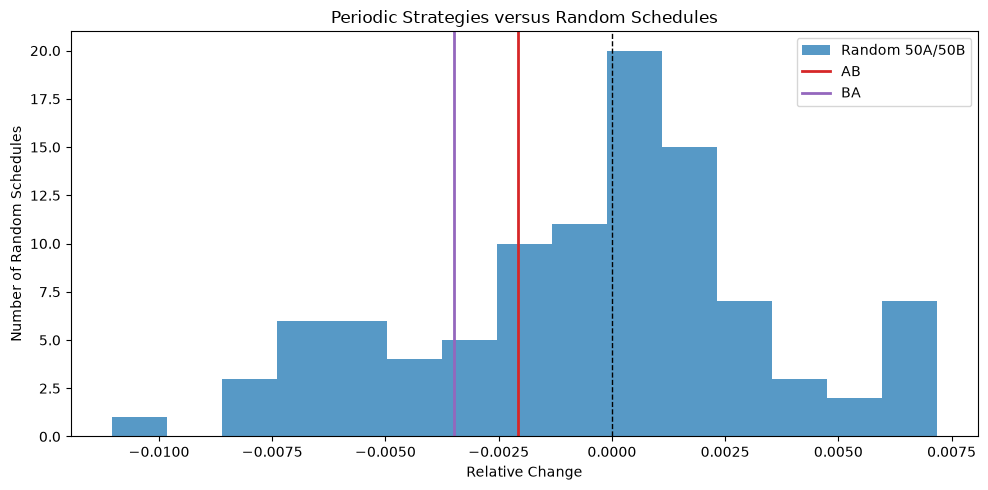

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    random_results["relative_change"],
    bins=15,
    alpha=0.75,
    label="Random 50A/50B",
)

ax.axvline(
    results["AB"].relative_change,
    color="tab:red",
    linewidth=2,
    label="AB",
)

ax.axvline(
    results["BA"].relative_change,
    color="tab:purple",
    linewidth=2,
    label="BA",
)

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Periodic Strategies versus Random Schedules")
ax.set_xlabel("Relative Change")
ax.set_ylabel("Number of Random Schedules")
ax.legend()

plt.tight_layout()
plt.show()

## Inspect budget exhaustion

The exhaustion step shows when removal stops and growth plus diffusion begin
to operate without further treatment.

In [12]:
def budget_exhaustion_step(result, budget):
    matches = np.flatnonzero(
        result.cost_history >= budget - 1e-2
    )
    return int(matches[0]) if matches.size else None


budget_table = pd.DataFrame(
    [
        {
            "strategy": name,
            "budget_exhaustion_step": budget_exhaustion_step(
                result,
                COMMON_BUDGET,
            ),
            "final_cost": result.final_cost,
            "relative_change": result.relative_change,
        }
        for name, result in results.items()
    ]
)

budget_table

,strategy,budget_exhaustion_step,final_cost,relative_change
0,A only,None,149107.484375,0.041958
1,B only,None,199967.171875,0.014206
2,AB,None,228212.656250,-0.002064
3,BA,None,229166.359375,-0.003486
4,A50B50,None,138087.875000,0.047051
5,B50A50,None,173466.421875,0.029926


## Interpretation

This condition provides stronger evidence than the original example because
all deterministic strategies use the same fixed budget and both block
controls remain losing.

The random-schedule distribution determines how specific the effect is to
periodic alternation. If most random schedules remain losing while AB and BA
are winning, the timing structure is important. If many random schedules are
also winning, the result still reflects a broader order-dependent policy
mixture rather than a uniquely periodic effect.